# Laboratorio 2 -Modelo de Gemini

In [68]:
import pandas as pd
from google import genai
import time
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/MalBehavD-V1-dataset.csv')

df.head()

,sha256,labels,0,1,2,3,4,5,6,7,...,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171,Unnamed: 172,Unnamed: 173,Unnamed: 174,Unnamed: 175,Unnamed: 176
0,5c18291c481a192ed5003084dab2d8a117fd3736359218...,0,LdrUnloadDll,CoUninitialize,NtQueryKey,NtDuplicateObject,GetShortPathNameW,GetSystemInfo,IsDebuggerPresent,GetSystemWindowsDirectoryW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4683faf3da550ffb594cf5513c4cbb34f64df85f27fd1c...,0,NtOpenMutant,GetForegroundWindow,NtQueryKey,DrawTextExW,NtSetInformationFile,RegQueryValueExA,LdrGetProcedureAddress,CoUninitialize,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9a0aea1c7290031d7c3429d0e921f107282cc6eab854ee...,0,GetForegroundWindow,DrawTextExW,GetSystemInfo,IsDebuggerPresent,GetSystemWindowsDirectoryW,NtQueryValueKey,RegCloseKey,GetFileAttributesW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,e0f3e4d5f50afd9c31e51dd9941c5a52d57c7c524f5d11...,0,NtQueryValueKey,LdrUnloadDll,GlobalMemoryStatus,WriteConsoleA,NtOpenKey,LdrGetProcedureAddress,NtTerminateProcess,NtClose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ec2b6d29992f13e74015ff0b129150b4afae15c593e4b7...,0,LdrUnloadDll,GetSystemTimeAsFileTime,NtOpenKey,WSAStartup,SetUnhandledExceptionFilter,NtTerminateProcess,NtClose,NtAllocateVirtualMemory,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Primero, vamos a juntar todas la secuencia de llamadas a APIS de cada archivo en un solo campo

In [3]:
def build_sequence(row):
    row_clean = row.dropna()
    return " ".join(row_clean.astype(str))


df['api_call_sequence'] = df.iloc[:, 2:].apply(build_sequence, axis = 1)

In [4]:
df['api_call_sequence'][0]

'LdrUnloadDll CoUninitialize NtQueryKey NtDuplicateObject GetShortPathNameW GetSystemInfo IsDebuggerPresent GetSystemWindowsDirectoryW NtClose GetFileVersionInfoSizeW NtOpenProcess GetFileAttributesW RegQueryValueExW NtMapViewOfSection RtlAddVectoredExceptionHandler GetFileSize RegOpenKeyExW SetErrorMode NtResumeThread NtAllocateVirtualMemory GetFileInformationByHandle LdrGetDllHandle NtFreeVirtualMemory NtQuerySystemInformation NtEnumerateValueKey RtlRemoveVectoredExceptionHandler NtReadFile NtOpenFile CoInitializeEx CreateThread NtUnmapViewOfSection RegQueryInfoKeyW GetSystemDirectoryW RegEnumKeyExW NtQueryDirectoryFile SetUnhandledExceptionFilter NtCreateFile NtCreateThreadEx GetSystemTimeAsFileTime GlobalMemoryStatusEx NtCreateMutant NtProtectVirtualMemory GetFileAttributesExW RegEnumValueW NtCreateSection NtOpenKey LdrGetProcedureAddress GetFileVersionInfoW NtOpenDirectoryObject GetFileType NtOpenKeyEx LdrLoadDll NtTerminateProcess NtQueryValueKey'

Vemos que tuvimos éxito, ahora vamos a tomar cada secuencia de llamadas unificada como si fuera una oración y las vamos a convertir a embbeddings

In [ ]:
client = genai.Client(api_key='MYKEY')

df['embeddings']  = None

texts = list(df["api_call_sequence"])

batch_size = 100
all_embeddings = []

for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]

    result = client.models.embed_content(
        model="gemini-embedding-001",
        contents=batch
    )

    all_embeddings.extend([emb.values for emb in result.embeddings])

    time.sleep(8)

df["embeddings"] = all_embeddings
df.to_pickle("dataset_with_embeddings.pkl")
print("Total embeddings:", len(all_embeddings))

Total embeddings: 2570


Ya con los embeddings, vamos a hacer un MLP con varias capas y cada embedding va a ser un input pero primero vamos a dividir el dataset y reducir su tamaño. 

In [43]:
y = df['labels']

x = np.array(df["embeddings"].tolist())

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_test  = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

In [45]:
print(torch.cuda.is_available()) 
print(torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

True
NVIDIA GeForce RTX 4060 Laptop GPU
cuda


In [46]:
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

Con todo preparado, vamos a armar un MLP con estas características:

- Una primera capa con 256 neuronas y una ReLu como activación
- Luego, otra capa de 128 neuronas y un ReLu
- Finalmente aplicamos una sigmoide y damos el output
- Cada capa interna tiene un dropout de 30% para que generalize mejor

In [59]:
class MalwareMLP(nn.Module):
    def __init__(self, input_dim):
        super(MalwareMLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = MalwareMLP(input_dim=X_train.shape[1]).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100

for epoch in range(epochs):

    model.train()
    optimizer.zero_grad()

    outputs = model(X_train).squeeze()
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/100, Loss: 0.6930
Epoch 2/100, Loss: 0.6908
Epoch 3/100, Loss: 0.6881
Epoch 4/100, Loss: 0.6839
Epoch 5/100, Loss: 0.6794
Epoch 6/100, Loss: 0.6735
Epoch 7/100, Loss: 0.6674
Epoch 8/100, Loss: 0.6594
Epoch 9/100, Loss: 0.6508
Epoch 10/100, Loss: 0.6404
Epoch 11/100, Loss: 0.6285
Epoch 12/100, Loss: 0.6161
Epoch 13/100, Loss: 0.6010
Epoch 14/100, Loss: 0.5847
Epoch 15/100, Loss: 0.5659
Epoch 16/100, Loss: 0.5472
Epoch 17/100, Loss: 0.5280
Epoch 18/100, Loss: 0.5070
Epoch 19/100, Loss: 0.4861
Epoch 20/100, Loss: 0.4625
Epoch 21/100, Loss: 0.4387
Epoch 22/100, Loss: 0.4167
Epoch 23/100, Loss: 0.3958
Epoch 24/100, Loss: 0.3755
Epoch 25/100, Loss: 0.3588
Epoch 26/100, Loss: 0.3390
Epoch 27/100, Loss: 0.3248
Epoch 28/100, Loss: 0.3066
Epoch 29/100, Loss: 0.2921
Epoch 30/100, Loss: 0.2767
Epoch 31/100, Loss: 0.2684
Epoch 32/100, Loss: 0.2656
Epoch 33/100, Loss: 0.2512
Epoch 34/100, Loss: 0.2416
Epoch 35/100, Loss: 0.2388
Epoch 36/100, Loss: 0.2350
Epoch 37/100, Loss: 0.2244
Epoch 38/1

In [65]:
model.eval()

with torch.no_grad():
    probs = model(X_test).squeeze()      
    predictions = (probs > 0.5).float()
    
y_true = y_test.cpu().numpy()
y_pred = predictions.cpu().numpy()
y_probs = probs.cpu().numpy()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.9377
Precision: 0.9244
Recall   : 0.9532
F1-score : 0.9386


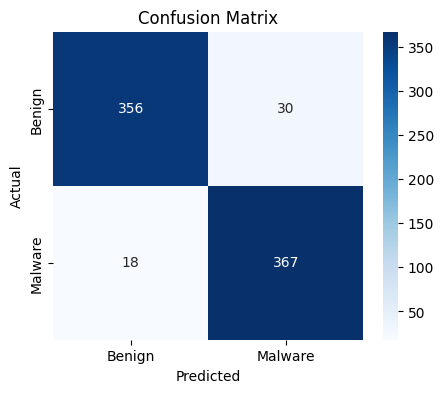

In [67]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malware"],
            yticklabels=["Benign", "Malware"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

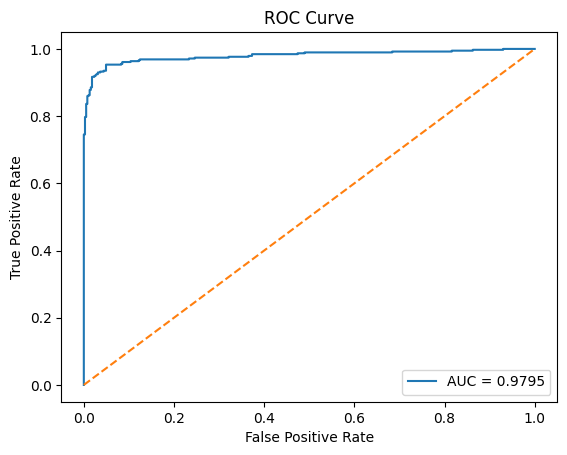

In [69]:
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Análisis de resultados

Vemos que el modelo que desarrollamos con los embeddings se desempeñó bastante bien, pues detectó correctamente casi todos los archivos de malware de forma correcta y los beningnos también, sin embargo el modelo es un poco mejor detectando malware pues el recall es de 0.95, eso quiere decir que de todo el malware presente logró detectar con éxito el 95% de todo el malware que había. A pesar de su efectividad, vemos que este modelo puede potencialmente dar un problema de falsas alarmas pues vemos que la tasa de falsos positivos es mayor que la de falsos negativos, por ende sería buena idea ajustarlo a la tasa real de malware en la realidad porque posiblemente esta sea baja. 